In [1]:
import math
import random
import numpy as np
import gymnasium as gym

from time import sleep
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from importnb import Notebook
with Notebook():
    from LabTrajectory import simulate_viewport_with_tiles
    from LabLatencyModel import LatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserTileRequest import UserTileRequestEvents

import sys
sys.path.append(r'c:\Users\es25591\Workspace\CacheVideoPredict360\Sources')

from Common.Utils import zipf

In [2]:
class EnvWrapper(gym.Env):
    """
    Simple wrapper that delegates all calls to an inner env.
    Subclass this to create your own wrappers.
    """

    def __init__(
        self, 
        n: int,
        n_layers: int,
        users_env: None,
        cache_env: None,
        latency_model: LatencyModel, 
    ):
        super().__init__()

        self.n = n  # number of tiles per row/column
        self.n_layers = n_layers  # number of layers (base + enhancement)
        
        self.gain_if_prefetched = 1.0
        self.loss_if_not_prefetched = -1.0

        self.theta = 0.5
        self.lam = 3.7183

        self.users_env = users_env
        self.cache_env = cache_env
        self.latency_model = latency_model

    def step(self, action):
        reward = 0.0
        info = {}

        ### STEP 1: prefetching segments in the cache based on action taken by agent ###
        by_video = self.cache_env.process_cache_prefetching(action)

        # print("Complete cache matrix by_video:")
        # print(f"Shape: {by_video.shape}")
        # for vid_idx in range(by_video.shape[0]):
        #     print(f"\nVideo {vid_idx}:")
        #     for layer_idx in range(by_video.shape[1]):
        #         print(f"  Layer {layer_idx}: {by_video[vid_idx, layer_idx]}")

        ### STEP 2: Generate user requests ###
        reqs = self.users_env.step(by_video)
        # print("User requests:", reqs)

        ### STEP 3: compute latencies for each request ###
        total_latency = 0.0
        for req in reqs:
            p = req.get("p", 0)
            u = req.get("u", 0)
            tiles = req.get("tiles", [])
            
            req_latency, tile_latencies = self.latency_model.total_request_latency(
                p, 
                u, 
                tiles
            )
            
            total_latency += req_latency
            # print(
            #     f"User {u}, DU {p}, total latency: {req_latency:.4f}s, tiles requested: {len(tiles)}, tiles received: {len(tile_latencies)}"
            # )            
        
        ### STEP 4: Calculate metrics: cache hits and misses, and reward ###
        cache_hits = 0
        cache_misses = 0
        for req in reqs:
            vid = req['video']
            tiles = req['tiles']
            # print(f"Request for video {vid} with tiles: {tiles}")

            for tile in tiles:
                tile_idx = tile['tile']
                layer = tile['layer']

                if by_video[vid][layer][tile_idx] >= 1:
                    cache_hits += 1
                else:
                    cache_misses += 1

        info['cache_hits'] = int(cache_hits)
        info['cache_misses'] = int(cache_misses)

        # compute reward for this video's action and add
        total_requests = sum(len(req.get('tiles', [])) for req in reqs)
        
        # Compute current_p: probability for each (vid, tile_idx) based on requests
        tile_counts = {}
        for req in reqs:
            vid = req["video"]
            tiles = req["tiles"]
            for tile in tiles:
                key = (vid, tile['layer'], tile['tile'])
                tile_counts[key] = tile_counts.get(key, 0) + 1

        # Normalize by total_requests to get probabilities
        current_p = {
            key: count / total_requests
            for key, count in tile_counts.items()
        }
    
        reward += self.compute_expected_cpt_reward(
            prefetched_tiles=by_video,
            current_p=current_p,
            requests=reqs
        )

        return {}, reward, False, info

    def compute_expected_cpt_reward(self, prefetched_tiles, current_p, requests) -> float:
        expected_reward = 0.0
        requested_tile_keys = set()
        for request in requests:
            vid = request['video']
            tiles = request['tiles']

            for tile in tiles:
                layer = tile['layer']
                tile_idx = tile['tile']
                tile_key = (vid, layer, tile_idx)
                
                p = float(current_p.get(tile_key, 0.0))
                w = self.prelec_w(p, theta=self.theta)
                
                if prefetched_tiles[vid][layer][tile_idx] >= 1:
                    expected_outcome = self.gain_if_prefetched
                    requested_tile_keys.add(tile_key)
                else:
                    expected_outcome = self.loss_if_not_prefetched
                
                v = self.cpt_value(expected_outcome, lam=self.lam)
                expected_reward += w * v

        return float(expected_reward)

    def prelec_w(self, p: float, theta: float = 0.65) -> float:
        if p <= 0.0: return 0.0
        if p >= 1.0: return 1.0
        return math.exp(-((-math.log(p)) ** theta))

    def cpt_value(
        self,
        x: float, 
        lam: float = 1.5
    ) -> float:
        if x >= 0:
            return x
        else:
            return -lam * (-x)

    def reset(self, **kwargs):
        _, info_users = self.users_env.reset(**kwargs)
        _, info_cache = self.cache_env.reset(**kwargs)
        # self.latency_model.reset(**kwargs)

        return None, {**info_users, **info_cache}

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # state shape: (seq_len, input_size)
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class LSTM_DQN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTM_DQN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM Layer: Takes sequence of viewports
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully Connected Layer: Maps LSTM output to Q-values (one per tile index)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden=None):
        # x shape: (batch, seq_len, input_size)
        
        # LSTM output shape: (batch, seq_len, hidden_size)
        lstm_out, hidden = self.lstm(x, hidden)
        
        # We only care about the output of the last time step for prediction
        last_time_step = lstm_out[:, -1, :]
        
        # Q-values
        q_values = self.fc(last_time_step)
        return q_values, hidden

class DQNAgent:
    def __init__(self, n_tiles, seq_len, learning_rate=1e-3, gamma=0.99, epsilon_start=1.0):
        self.n_tiles = n_tiles
        self.seq_len = seq_len
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995
        
        self.policy_net = LSTM_DQN(n_tiles, 128, n_tiles).to(device)
        self.target_net = LSTM_DQN(n_tiles, 128, n_tiles).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(
            self.policy_net.parameters(), 
            lr=learning_rate
        )

        self.criterion = nn.MSELoss()
        self.memory = ReplayMemory(capacity=10000)
        self.batch_size = 64

    def select_action(self, state_seq):
        """
        state_seq: numpy array of shape (seq_len, n_tiles)
        Returns: integer index of the predicted center tile
        """
        if random.random() < self.epsilon:
            return random.randrange(self.n_tiles)
        else:
            with torch.no_grad():
                # Convert to tensor and add batch dimension: (1, seq_len, n_tiles)
                state_tensor = torch.FloatTensor(state_seq).unsqueeze(0).to(device)
                q_values, _ = self.policy_net(state_tensor)
                return q_values.argmax().item()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return 0.0
        
        transitions = self.memory.sample(self.batch_size)
        state_batch, action_batch, reward_batch, next_state_batch, done_batch = zip(*transitions)

        # Convert to tensors
        state_batch = torch.FloatTensor(np.array(state_batch)).to(device)      # (B, Seq, Input)
        next_state_batch = torch.FloatTensor(np.array(next_state_batch)).to(device)
        action_batch = torch.LongTensor(action_batch).unsqueeze(1).to(device)  # (B, 1)
        reward_batch = torch.FloatTensor(reward_batch).to(device)
        done_batch = torch.FloatTensor(done_batch).to(device)

        # Compute Q(s, a)
        q_values, _ = self.policy_net(state_batch)
        state_action_values = q_values.gather(1, action_batch).squeeze(1)

        # Compute V(s')
        with torch.no_grad():
            next_q_values, _ = self.target_net(next_state_batch)
            next_state_values = next_q_values.max(1)[0]
            expected_state_action_values = reward_batch + (self.gamma * next_state_values * (1 - done_batch))

        # Loss and Optimize
        loss = self.criterion(state_action_values, expected_state_action_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [4]:
def index_to_fov_mask(center_idx, n):
    """
    Converts a predicted center tile index into a binary mask of neighbors.
    Simulates a 3x3 (or specific FOV) grid around the center.
    """
    mask = np.zeros(n*n, dtype=int)
    
    # Grid coordinates
    cy, cx = divmod(center_idx, n)
    
    # Define a simple FOV range (e.g., center + immediate neighbors)
    # Adjust range to match the desired viewport size (roughly 90 deg)
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            ny, nx = cy + dy, cx + dx
            if 0 <= ny < n and 0 <= nx < n:
                mask[ny * n + nx] = 1
                
    return mask

Experiment ===================
Total users: 30
Cache capacity: 100000000.0MB
Video matrix: 100x2x16

Episode 1/500, Total Reward: -58659.9370, Info: {'cache_hits': 69, 'cache_misses': 529}
Episode 1/500, Total Reward: -58659.9370, Info: {'cache_hits': 69, 'cache_misses': 529}
Episode 2/500, Total Reward: -59991.6515, Info: {'cache_hits': 47, 'cache_misses': 553}
Episode 2/500, Total Reward: -59991.6515, Info: {'cache_hits': 47, 'cache_misses': 553}
Episode 3/500, Total Reward: -56649.0582, Info: {'cache_hits': 55, 'cache_misses': 549}
Episode 3/500, Total Reward: -56649.0582, Info: {'cache_hits': 55, 'cache_misses': 549}
Episode 4/500, Total Reward: -53712.2968, Info: {'cache_hits': 37, 'cache_misses': 561}
Episode 4/500, Total Reward: -53712.2968, Info: {'cache_hits': 37, 'cache_misses': 561}
Episode 5/500, Total Reward: -57939.0657, Info: {'cache_hits': 42, 'cache_misses': 556}
Episode 5/500, Total Reward: -57939.0657, Info: {'cache_hits': 42, 'cache_misses': 556}
Episode 6/500, Tota

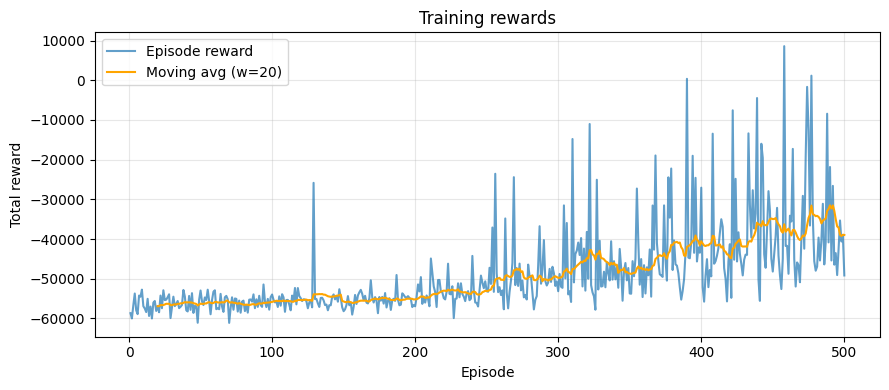

In [5]:
if __name__ == "__main__":
    n_episodes = 500
    n_steps = 300
    n_users = 30
    alpha = 1.0
    total_videos = 100
    n_gops = 300
    n_layers = 2
    n = 4
    n_tiles = n * n
    max_capacity = 100e6  # 50 MB
    
    # Hyperparameters for RL
    seq_len = 5  # LSTM sequence length (history window)

    # Initialize User Environment
    users_env = UserTileRequestEvents(
        n_users=n_users,
        total_videos=total_videos,
        n_gops=n_gops,
        n_layers=n_layers,
        n_tiles=n_tiles,
        n=n,
        users_viewport_tiles=None,
        requested_videos=None
    )

    cache_env = CacheEngineEnv(
        n_tiles=n*n,
        n_videos=total_videos,
        cache_capacity=max_capacity,
    )

    # Create latency model (replace numbers with your real config)
    P = 1; U = n_users
    lat_model = LatencyModel(
        P=P, 
        U=U,
        R_M_D=80e6,   # 640 Mbps -> 80e6 B/s 
        R_C_M=1.25e9, # 10 Gbps -> 1.25e9 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, U), 40e6, dtype=float),       # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, U), 5.0, dtype=float),    # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1 ms
        mec_fixed_delay=0.005,   # 5 ms
        cloud_fixed_delay=0.05   # 50 ms
    )

    env = EnvWrapper(
        n=n,
        n_layers=n_layers,
        users_env=users_env, 
        cache_env=cache_env, 
        latency_model=lat_model
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {n_users}\n"
        f"Cache capacity: {max_capacity}MB\n"
        f"Video matrix: {total_videos}x{n_layers}x{n*n}\n"
        f"==============================\n"
    )

    agent = DQNAgent(n_tiles=n_tiles, seq_len=seq_len)

    scores = []
    for ep in range(n_episodes):

        obs, info = env.reset()
        total_reward = 0.0

        # User State History: Dictionary to track last 'seq_len' viewports per user
        # Initialize with zeros
        user_histories = {}
        for u in range(n_users):
            user_histories[u] = deque(
                [np.zeros(n*n) for _ in range(seq_len)], maxlen=seq_len
            )

        requested_videos = info['requested_videos']
        viewport_tiles = info['viewport_tiles']
        
        for step in range(n_steps):
            actions = []
            user_action_indices = {} # Store discrete action (center tile) for training
            
            for u in range(n_users):
                # Construct state from history
                cur_state_seq = np.array(user_histories[u]) # Shape (seq_len, 16)
                
                # Agent chooses center tile
                center_tile_idx = agent.select_action(cur_state_seq)
                user_action_indices[u] = center_tile_idx
                
                # Convert center tile to mask for the Env
                predicted_mask = index_to_fov_mask(center_idx=center_tile_idx, n=n)
                
                actions.append({
                    'user': u,
                    'video': requested_videos[u],
                    'tiles': predicted_mask
                })

            obs, reward, _, info = env.step(actions)
            total_reward += float(reward)

            # 3. Process Feedback and Train
            # We treat the aggregate reward as the reward for every user (Cooperative setting)
            # Or normalize it by n_users. Here we use raw reward / n_users to keep scale manageable.
            step_reward = float(reward) / n_users
            
            # We need the GROUND TRUTH viewports of this step to update histories for next step
            # 'users_env.step' inside EnvWrapper has advanced. We need to peek at what actually happened.
            # We can retrieve the "actual" requested tiles from the EnvWrapper logic or simpler:
            # Check 'users_viewport_tiles' at the current step.
            
            for u in range(n_users):
                # Get the state used for prediction
                state_seq = np.array(user_histories[u])
                
                # Get the actual viewport mask for this step (Ground Truth)
                actual_mask = np.zeros(n*n)
                for tile in viewport_tiles[u][step]:
                    tx, ty = tile
                    if 0 <= tx < n and 0 <= ty < n:
                        actual_mask[ty * n + tx] = 1
                
                # Update history (Next State)
                user_histories[u].append(actual_mask)
                next_state_seq = np.array(user_histories[u])
                
                # Store in Replay Buffer
                # We store the experience: (State, Action_Index, Reward, Next_State, Done)
                done = (step == n_steps - 1)
                agent.memory.push(
                    state_seq, 
                    user_action_indices[u], 
                    step_reward, 
                    next_state_seq, 
                    done
                )
            
            # Train the agent (once per step, or multiple times)
            agent.train_step()

        # Update Target Network and Decay Epsilon
        if ep % 5 == 0:
            agent.update_target_network()
        agent.update_epsilon()

        print(
            f"Episode {ep+1}/{n_episodes}, "
            f"Total Reward: {total_reward:.4f}, "
            f"Info: {info}"
        )

        scores.append(total_reward)

    import matplotlib.pyplot as plt

    episodes = range(1, len(scores) + 1)
    plt.figure(figsize=(9, 4))
    plt.plot(episodes, scores, label="Episode reward", alpha=0.7)

    # Moving average for smoothing
    w = max(1, min(20, len(scores) // 10))
    if w > 1:
        ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
        plt.plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")

    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title("Training rewards")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()